In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jayjoshi37/sleep-screen-time-and-stress-analysis/sleep_mobile_stress_dataset_15000.csv


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [3]:
data = pd.read_csv('/kaggle/input/datasets/jayjoshi37/sleep-screen-time-and-stress-analysis/sleep_mobile_stress_dataset_15000.csv', index_col = 'user_id')
data.head()

,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
user_id,,,,,,,,,,,,
1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


# EDA

In [4]:
print('Shape of data is:',data.shape)

Shape of data is: (15000, 12)


In [5]:
print('columns in dataset are:')
c = 0
for i in data.columns.tolist():
    c += 1
    print(f'{c}.',i)

columns in dataset are:
1. age
2. gender
3. occupation
4. daily_screen_time_hours
5. phone_usage_before_sleep_minutes
6. sleep_duration_hours
7. sleep_quality_score
8. stress_level
9. caffeine_intake_cups
10. physical_activity_minutes
11. notifications_received_per_day
12. mental_fatigue_score


In [6]:
print('Null entries in each column :')
data.isnull().sum()

Null entries in each column :


age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups                0
physical_activity_minutes           0
notifications_received_per_day      0
mental_fatigue_score                0
dtype: int64

In [7]:
print('Datatype of columns:')
data.dtypes

Datatype of columns:


age                                   int64
gender                               object
occupation                           object
daily_screen_time_hours             float64
phone_usage_before_sleep_minutes      int64
sleep_duration_hours                float64
sleep_quality_score                 float64
stress_level                        float64
caffeine_intake_cups                  int64
physical_activity_minutes             int64
notifications_received_per_day        int64
mental_fatigue_score                float64
dtype: object

# Visualizations 


In [8]:
target = 'mental_fatigue_score'  #our target column to predict and the column we focus on to work w.r.t.

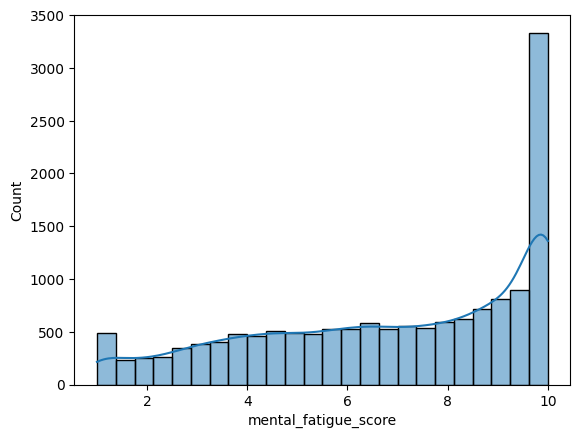

In [9]:
sns.histplot(x = data['mental_fatigue_score'], kde = True)
plt.show()

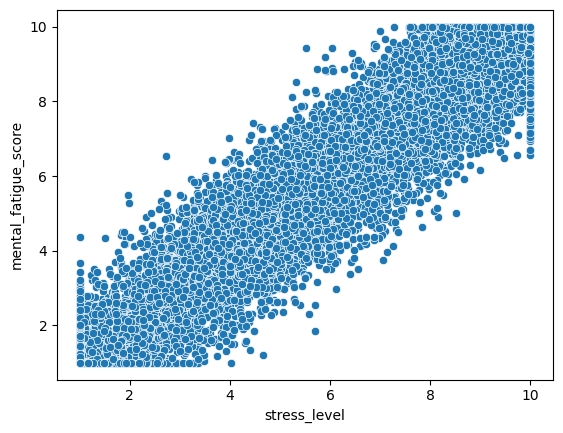

In [10]:
#correlation between stress_level and mental_fatigue_score
sns.scatterplot(data = data, x = 'stress_level', y = target)
plt.show()

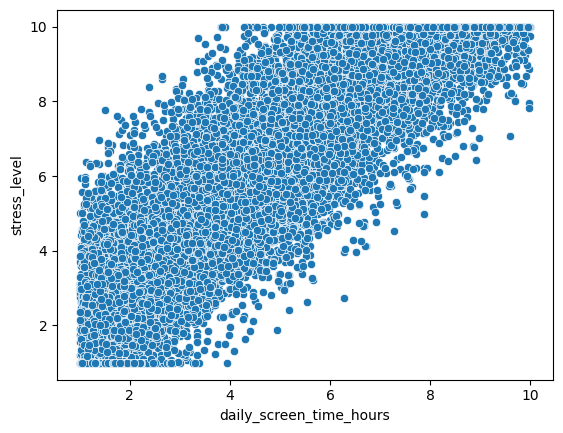

In [11]:
#correlation between daily_screen_time_hours and stress_level

sns.scatterplot(data = data, x = 'daily_screen_time_hours', y = 'stress_level')
plt.show()



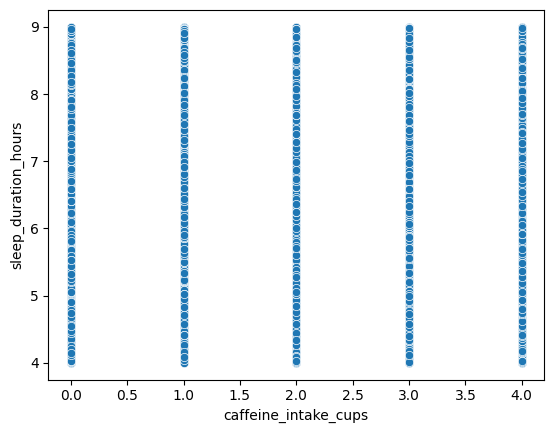

In [12]:
#correlation between caffeine_intake_cups and sleep_duration_hours

sns.scatterplot(data = data, x = 'caffeine_intake_cups', y = 'sleep_duration_hours')
plt.show()

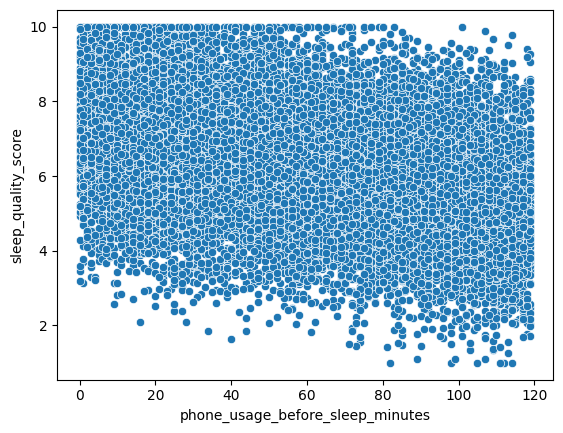

In [13]:
#correlation between phone_usage_before_sleep_minutes and sleep_quality_score

sns.scatterplot(data = data, x = 'phone_usage_before_sleep_minutes', y = 'sleep_quality_score')
plt.show()



<Axes: >

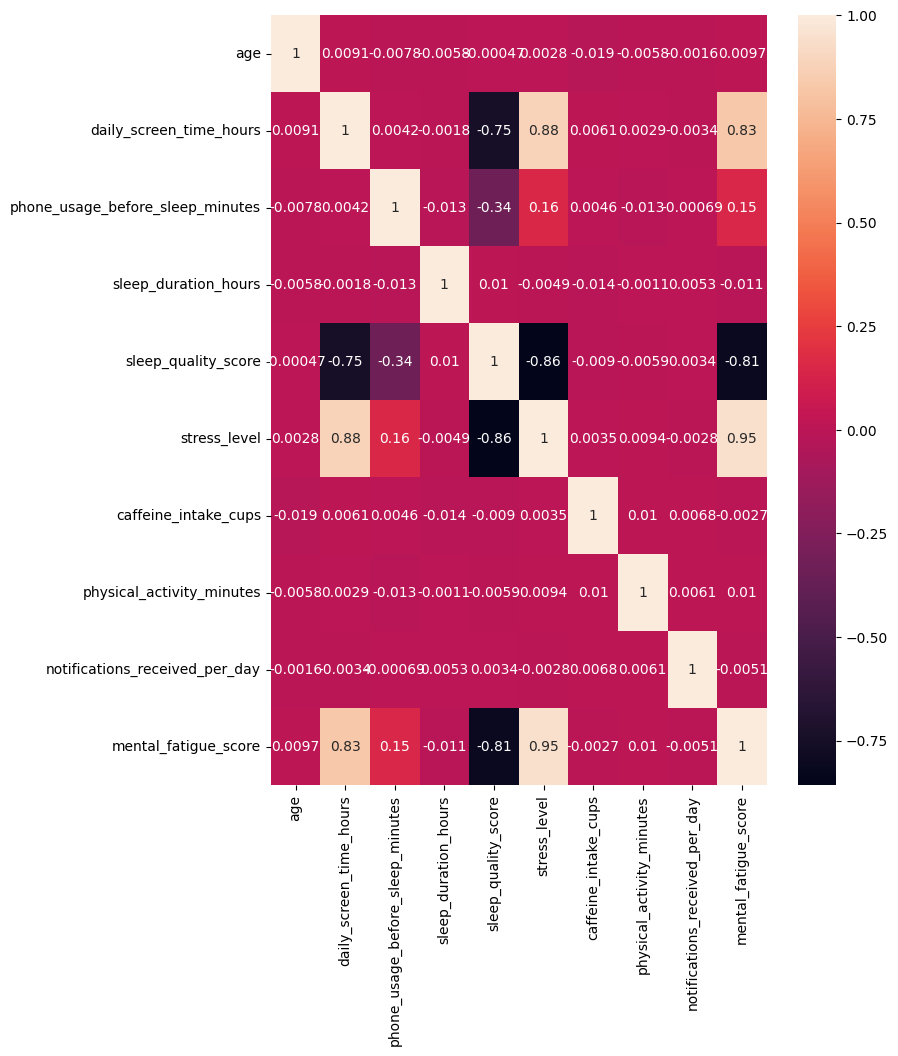

In [14]:
cols = data.select_dtypes(include='number').columns

plt.figure(figsize = (8,10))
sns.heatmap(data[cols].corr(),annot = True)

# From the above visualizations, we can observe that there is:

1. Slight negative correlation between phone_usage_before_sleep_minutes and sleep_quality_score

2. No correlation between caffeine_intake_cups and sleep_duration_hours

3. Highly positive correlation between stress_level and mental_fatigue_score

4. Highly positive correlation between daily_screen_time_hours and stress_level

In [15]:
for i in cols:            #scaling the values to similar range
    data[i] = data[i]/max(data[i])



X = data[cols[:-1]].values
y = data[target]



In [16]:
cols

Index(['age', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes',
       'sleep_duration_hours', 'sleep_quality_score', 'stress_level',
       'caffeine_intake_cups', 'physical_activity_minutes',
       'notifications_received_per_day', 'mental_fatigue_score'],
      dtype='object')

In [17]:
X_train,X_test, y_train,y_test = train_test_split(X, y, random_state = 42, test_size = 0.3)

In [18]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [19]:
y_pred = model.predict(X_train)

mean_squared_error(y_train,y_pred)

0.0011119785623047618

In [20]:
y_test_pred = model.predict(X_test)

mean_squared_error(y_test,y_test_pred)

0.007659446658444444